# A3 02 — Community fidelity and change after fence removal

## Research questions
1. Does the OPC bone assemblage reflect the living wild-mammal community?
2. Does it capture changes observed after removal of the internal fence in 2007?

All direct comparisons use the shared taxon set prepared in A3 01. Counts are converted to relative composition before comparing datasets because aerial totals are orders of magnitude larger than bone totals. Results describe change after the fence transition; they do not by themselves establish that fence removal caused the change.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'scripts'))
from a3_common import *
processed_dir, output_dir = ensure_a3_directories(ROOT)
aerial = pd.read_pickle(processed_dir / 'aerial_primary.pkl')
bones = pd.read_pickle(processed_dir / 'bones_primary_excluding_2024.pkl')
decisions = pd.read_csv(processed_dir / 'taxon_decisions.csv')
shared_taxa = decisions.loc[decisions['matched_analysis'], 'taxon'].tolist()


## Analysis 1 — Is sampling adequate?

This audit reports how many annual samples and individuals or specimens support each comparison. It is descriptive because a statistical test cannot compensate for a tiny sample.

**Plain-language example.** Percentages based on bone MNI of 10 are less precise than percentages based on 5,000 aerially counted animals, even when both samples are converted to proportions.


In [2]:
audit = sample_audit(aerial[aerial['Species'].isin(shared_taxa)], bones[bones['Species'].isin(shared_taxa)])
audit.to_csv(output_dir / 'A3_02_sampling_adequacy.csv', index=False)
audit


,dataset,sector,year_samples,total_count,median_sample_count,minimum_sample_count,maximum_sample_count,samples_below_10
0,aerial,Eastern,20,42708.0,2047.5,935.0,3965.0,0
1,aerial,Western,17,113086.0,6507.0,4556.0,9820.0,0
2,bones,Eastern,14,293.0,18.0,2.0,54.0,3
3,bones,Western,11,224.0,16.0,1.0,57.0,5


### Interpretation

The matched primary bone series contains 14 Eastern and 11 Western sector-years. Median summed matched-taxon MNI is 18 and 16, respectively; 3 Eastern and 5 Western sector-years contain matched-taxon MNI below 10 within that single sector × estimated-death-year sample. The ≥10 threshold refers to summed MNI across eligible matched taxa and contributing, spatially separated transects. It does not mean 10 skeletal elements, taxa, transects, or aerially counted animals. Aerial samples remain orders of magnitude larger. Bone temporal results therefore remain aggregated effect sizes and descriptive summaries unless the additional feasibility audit in A3 04 shows adequate replication.


## Analysis 2 — Overall and sector-specific live–bone fidelity

Bray-Curtis dissimilarity measures the difference between two relative compositions. A value of 0 means identical proportions; values closer to 1 indicate larger differences. Pearson correlation measures agreement in proportional magnitude, while Spearman correlation measures agreement in taxon ordering.

**Plain-language example.** A census with 400 zebra among 1,000 animals and a bone assemblage in which zebra MNI is 8 out of a total MNI of 20 both contain 40% zebra. Their abundance units and totals differ greatly, but their proportional representation is the same.


In [3]:
live_sector = aggregate_composition(aerial, shared_taxa, ['Sector'])
bone_sector = aggregate_composition(bones, shared_taxa, ['Sector'])
live_all = aerial[aerial['Species'].isin(shared_taxa)].groupby('Species')['Total'].sum()
bone_all = bones[bones['Species'].isin(shared_taxa)].groupby('Species')['Total'].sum()

rows = [{'comparison': 'OPC overall', **composition_comparison(live_all, bone_all)}]
for sector in SECTORS:
    rows.append({'comparison': f'{sector}: bones vs living', **composition_comparison(live_sector.loc[sector], bone_sector.loc[sector])})
for bone_s in SECTORS:
    for live_s in SECTORS:
        rows.append({'comparison': f'{bone_s} bones vs {live_s} living', **composition_comparison(live_sector.loc[live_s], bone_sector.loc[bone_s])})
fidelity = pd.DataFrame(rows).drop_duplicates('comparison')
fidelity.to_csv(output_dir / 'A3_02_fidelity_results.csv', index=False)
fidelity.round(3)


,comparison,bray_curtis,pearson,spearman,taxa_compared
0,OPC overall,0.358,0.789,0.763,15
1,Eastern: bones vs living,0.390,0.631,0.828,15
2,Western: bones vs living,0.378,0.821,0.668,15
3,Eastern bones vs Eastern living,0.390,0.631,0.828,15
4,Eastern bones vs Western living,0.301,0.834,0.716,15
5,Western bones vs Eastern living,0.466,0.576,0.745,15
6,Western bones vs Western living,0.378,0.821,0.668,15


### Interpretation and copy-ready results

Overall live–bone fidelity was moderate (Bray–Curtis = 0.358; Pearson r = 0.789; Spearman rho = 0.763; 15 taxa). Western bones matched the Western living community more closely (Bray–Curtis = 0.378, r = 0.821) than Eastern bones matched the expanded Eastern living community (Bray–Curtis = 0.390, r = 0.631). Eastern bones were still closer to the Western living composition (Bray–Curtis = 0.301) than to the Eastern living composition (0.390), consistent with spatial mixing and/or temporal averaging; this pattern alone cannot distinguish those explanations.


## Analysis 3 — How did the living community differ after fence removal?

The fence was removed in March 2007, before the September aerial census. Sweetwaters aerial totals from 2000, 2002, and 2003 extend the Eastern pre-removal series, so the East now has five pre-removal years (2000, 2002, 2003, 2005, and 2006); the West still has only 2005 and 2006. Observations from 2007 onward are post-removal. We report Bray–Curtis turnover and taxon-level proportional changes. PERMANOVA is not used as a common primary period test because the West has only two independent pre-removal years, compared with 15 post-removal years. Applying an inferential period test only in the East would make the sector analyses inconsistent, so both sectors are summarized with the same descriptive effect sizes. Block data are not analytical replicates in any A3 analysis and do not affect this decision.

**Plain-language example.** We can describe how two photographs differ even when only two early photographs exist, but two photographs are not enough to estimate reliably how variable the earlier period normally was.


In [4]:
period_rows = []
aerial_period_changes = []
for sector in SECTORS:
    sector_data = aerial[aerial['Sector'].eq(sector)]
    composition = period_composition(sector_data, shared_taxa)
    pre = composition.loc[(sector, PRE_FENCE_LABEL)]
    post = composition.loc[(sector, POST_FENCE_LABEL)]
    comparison = composition_comparison(pre, post)
    period_rows.append({'sector': sector, 'pre_years': int(sector_data.loc[sector_data['Year'] < POST_FENCE_YEAR, 'Year'].nunique()),
                        'post_years': int(sector_data.loc[sector_data['Year'] >= POST_FENCE_YEAR, 'Year'].nunique()),
                        'bray_curtis_turnover': comparison['bray_curtis']})
    aerial_period_changes.append(pd.DataFrame({'sector': sector, 'taxon': shared_taxa,
                                               'post_minus_pre': (post - pre).reindex(shared_taxa).values}))
aerial_period_summary = pd.DataFrame(period_rows)
aerial_period_summary.to_csv(output_dir / 'A3_02_aerial_period_summary.csv', index=False)
pd.concat(aerial_period_changes).to_csv(output_dir / 'A3_02_aerial_period_taxon_changes.csv', index=False)
aerial_period_summary.round(3)


,sector,pre_years,post_years,bray_curtis_turnover
0,Eastern,5,15,0.239
1,Western,2,15,0.334


### Interpretation

Five Eastern and two Western pre-removal aerial years were compared with 15 post-removal years per sector. Bray–Curtis turnover was 0.239 in the East and 0.334 in the West, indicating greater proportional reorganization in the West. In the West, the largest changes remained a decrease in plains zebra (-26.9 percentage points) and increases in buffalo (+13.8) and impala (+13.2). In the expanded East series, plains zebra decreased (-13.3 points), while impala (+7.9), Thomson's gazelle (+7.1), and buffalo (+3.7) increased. These differences do not establish that fence removal caused them.


## Analysis 4 — Do bones track the direction of change?

For each sector and taxon, we subtract the pre-removal relative abundance (through 2006) from the post-removal relative abundance (2007 onward). Positive values mean that the taxon became more prominent; negative values mean that it became less prominent. Correlation measures whether living and bone changes point in similar directions.

Because many annual bone samples are small, this is an aggregated descriptive comparison rather than an annual bone PERMANOVA.


In [5]:
change_rows = []
change_tables = []
for sector in SECTORS:
    live_change = change_vector(aerial, shared_taxa, sector)
    bone_change = change_vector(bones, shared_taxa, sector)
    cmp = composition_comparison(live_change.abs(), bone_change.abs())
    pear = pearsonr(live_change, bone_change).statistic
    spear = spearmanr(live_change, bone_change).statistic
    live_turn = composition_comparison(*[period_composition(aerial[aerial['Sector'].eq(sector)], shared_taxa).loc[(sector, p)] for p in [PRE_FENCE_LABEL, POST_FENCE_LABEL]])['bray_curtis']
    bone_turn = composition_comparison(*[period_composition(bones[bones['Sector'].eq(sector)], shared_taxa).loc[(sector, p)] for p in [PRE_FENCE_LABEL, POST_FENCE_LABEL]])['bray_curtis']
    change_rows.append({'sector': sector, 'change_pearson': pear, 'change_spearman': spear, 'living_pre_post_BC': live_turn, 'bone_pre_post_BC': bone_turn})
    change_tables.append(pd.DataFrame({'sector': sector, 'taxon': shared_taxa, 'living_change': live_change.reindex(shared_taxa).values, 'bone_change': bone_change.reindex(shared_taxa).values}))
change_results = pd.DataFrame(change_rows)
pd.concat(change_tables).to_csv(output_dir / 'A3_02_taxon_change_vectors.csv', index=False)
change_results.to_csv(output_dir / 'A3_02_change_tracking_results.csv', index=False)
change_results.round(3)


,sector,change_pearson,change_spearman,living_pre_post_BC,bone_pre_post_BC
0,Eastern,0.670,0.757,0.239,0.283
1,Western,-0.271,-0.059,0.334,0.233


### Interpretation and copy-ready results

With the three historical Eastern aerial years added, bone changes showed moderately strong positive correspondence with living changes in the East (Pearson r = 0.670, p = 0.006; Spearman rho = 0.757). This is substantially stronger than the earlier two-pre-year estimate. In the West, where no additional pre-removal years were available, Pearson correlation remained negative (r = -0.271, p = 0.329) and rank correlation was essentially zero (rho = -0.059). Living turnover was larger in the West (Bray–Curtis = 0.334) than the East (0.239), while bone turnover was 0.233 in the West and 0.283 in the East. Thus, Eastern bones now show evidence of tracking taxon-specific period change, whereas Western change correspondence remains unsupported.


## Analysis 5 — Which taxa explain live–bone mismatch?

Each taxon's absolute difference in relative abundance is expressed as a percentage of the total Bray-Curtis difference. This is a transparent group-mean contribution decomposition, not conventional sample-pair SIMPER.

**Plain-language example.** If the total mismatch is a pie, this table shows how much of the pie is associated with each taxon and whether that taxon is more prominent in living or bone data.


In [6]:
drivers = taxon_contributions(live_all, bone_all)
drivers.to_csv(output_dir / 'A3_02_taxon_contributions.csv', encoding='utf-8')
drivers.round(3)


,live_relative,bone_relative,absolute_difference,percent_of_bray_curtis,direction
Species,,,,,
Aepyceros melampus,0.220,0.060,0.160,22.346,higher in living
Equus burchellii,0.321,0.478,0.157,21.907,higher in bones
Syncerus caffer,0.175,0.077,0.098,13.625,higher in living
Phacochoerus africanus,0.027,0.103,0.075,10.533,higher in bones
Giraffa camelopardalis,0.022,0.075,0.054,7.499,higher in bones
Eudorcas thomsonii,0.093,0.046,0.047,6.517,higher in living
Kobus ellipsiprymnus,0.013,0.048,0.036,4.962,higher in bones
Nanger granti,0.061,0.029,0.032,4.405,higher in living
Loxodonta africana,0.031,0.012,0.019,2.676,higher in living


## Analysis 6 — Visualize taxon-level agreement

These figures show the observations behind the reported Pearson and Spearman correlations. Each point is one matched taxon, labelled with a two-letter code. The red line and equation describe the least-squares relationship; the dashed 1:1 line represents perfect live–bone agreement.

**Plain-language example.** A correlation coefficient gives one summary number. The scatterplot shows whether that number reflects most taxa or is driven by only one or two conspicuous taxa.


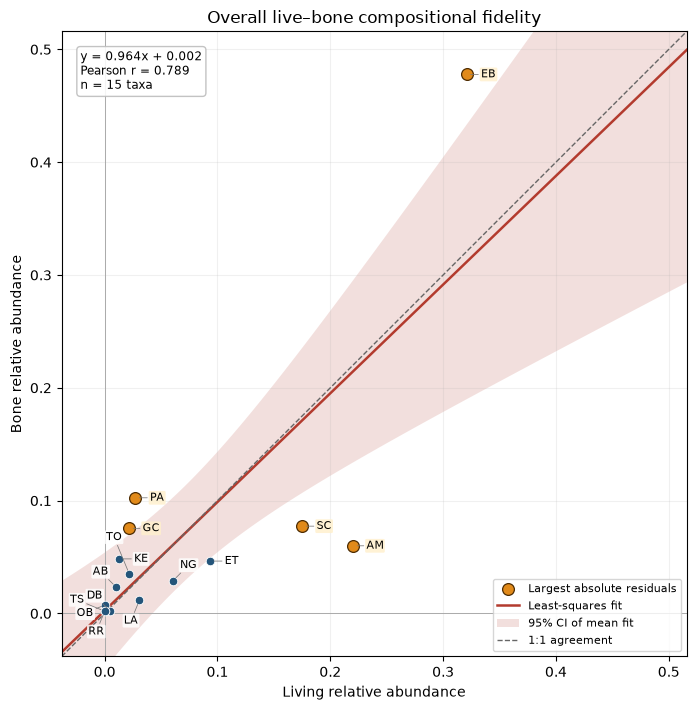

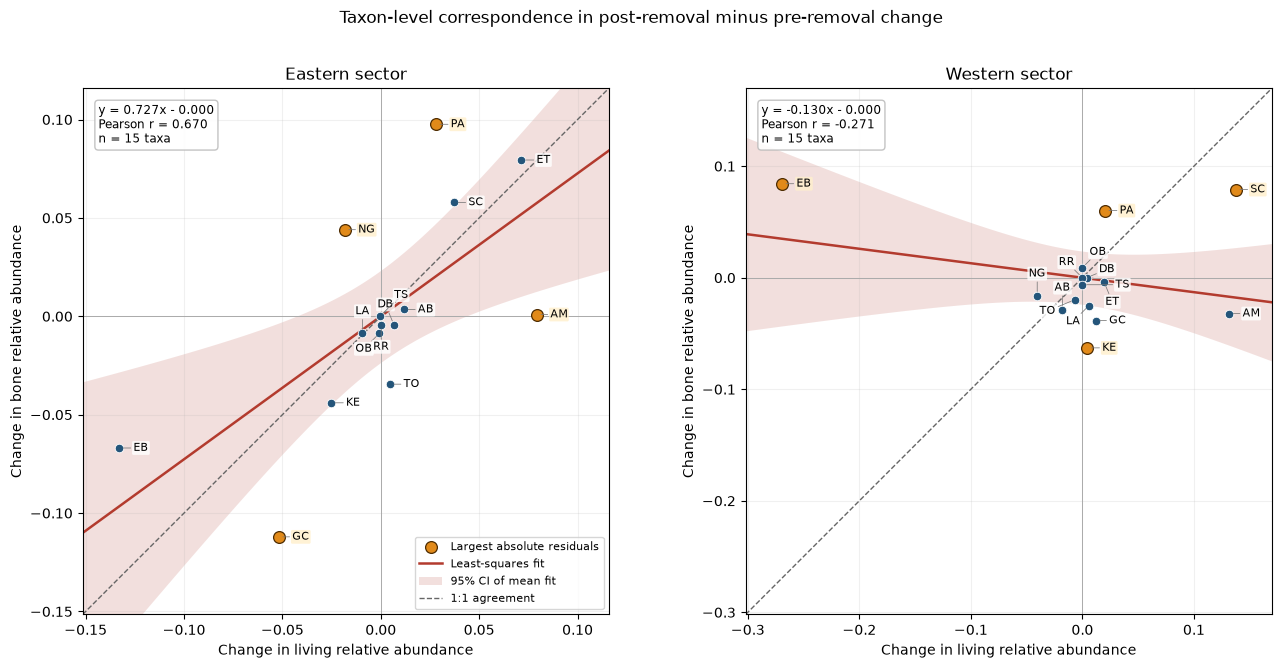

,figure,sector,slope,intercept,pearson,pearson_p,spearman,n_taxa,highlighted_taxa
0,overall fidelity,OPC,0.964,0.002,0.789,0.000,0.763,15,"EB, AM, SC, PA, GC"
1,period change,Eastern,0.727,-0.000,0.670,0.006,0.757,15,"PA, GC, NG, AM"
2,period change,Western,-0.130,-0.000,-0.271,0.329,-0.059,15,"SC, PA, KE, EB"


In [7]:
import matplotlib.pyplot as plt

live_plot = live_all / live_all.sum()
bone_plot = bone_all / bone_all.sum()
figure_stats = []

fig, ax = plt.subplots(figsize=(7.6, 7.2))
stats = labeled_regression_panel(
    ax, live_plot, bone_plot, 'Overall live–bone compositional fidelity',
    'Living relative abundance', 'Bone relative abundance', highlight_count=5)
figure_stats.append({'figure': 'overall fidelity', 'sector': 'OPC', **stats})
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()
fig.savefig(output_dir / 'A3_02_overall_fidelity_scatter.png', dpi=300, bbox_inches='tight')
fig.savefig(output_dir / 'A3_02_overall_fidelity_scatter.pdf', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.6))
for ax, sector in zip(axes, SECTORS):
    live_delta = change_vector(aerial, shared_taxa, sector)
    bone_delta = change_vector(bones, shared_taxa, sector)
    stats = labeled_regression_panel(
        ax, live_delta, bone_delta, f'{sector} sector',
        'Change in living relative abundance', 'Change in bone relative abundance', highlight_count=4)
    figure_stats.append({'figure': 'period change', 'sector': sector, **stats})
axes[0].legend(loc='lower right', fontsize=8)
fig.suptitle('Taxon-level correspondence in post-removal minus pre-removal change', y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(output_dir / 'A3_02_change_correspondence_scatter.png', dpi=300, bbox_inches='tight')
fig.savefig(output_dir / 'A3_02_change_correspondence_scatter.pdf', bbox_inches='tight')
plt.show()

figure_stats = pd.DataFrame(figure_stats)
figure_stats.to_csv(output_dir / 'A3_02_scatter_figure_statistics.csv', index=False)
figure_stats.round(3)


**Fig. A3.1. Correlation between living-population and bone-assemblage relative abundances for 15 matched wild-mammal taxa in Ol Pejeta Conservancy, Kenya.** Pearson correlation: r = 0.789, p < 0.001. Totals were summed across the available aerial census years, 2000–2023, including Sweetwaters totals for 2000, 2002, and 2003 as Eastern observations, and estimated bone death years, 1978–2014; n(live) = 155,794 total matched aerial census counts and n(dead) = 517 summed matched-taxon MNI. The solid red line is the least-squares fit, the dashed line represents 1:1 agreement, and shading is the 95% confidence interval of the mean fitted relationship.

**Fig. A3.2. Correlation between changes in living-population and bone-assemblage relative abundances after removal of the internal fence in March 2007.** Change was calculated as post-removal (2007+) minus pre-removal (through 2006) relative abundance for 15 matched taxa. The Eastern living comparison uses five pre-removal aerial years and the Western comparison uses two. Eastern sector: r = 0.670, p = 0.006; Western sector: r = -0.271, p = 0.329. The solid red lines are least-squares fits, dashed lines represent 1:1 agreement, and horizontal and vertical lines mark zero change.

**Taxon codes:** AM — *Aepyceros melampus* (impala); AB — *Alcelaphus buselaphus* (hartebeest); DB — *Diceros bicornis* (black rhinoceros); EB — *Equus burchellii* (plains zebra); ET — *Eudorcas thomsonii* (Thomson's gazelle); GC — *Giraffa camelopardalis* (giraffe); KE — *Kobus ellipsiprymnus* (waterbuck); LA — *Loxodonta africana* (African elephant); NG — *Nanger granti* (Grant's gazelle); OB — *Oryx beisa* (beisa oryx); PA — *Phacochoerus africanus* (warthog); RR — *Redunca redunca* (bohor reedbuck); SC — *Syncerus caffer* (buffalo); TO — *Taurotragus oryx* (common eland); TS — *Tragelaphus scriptus* (bushbuck).

**Highlighted taxa.** Orange points are the taxa with the largest absolute residuals from the fitted line; this is a descriptive highlighting rule, not a formal outlier test. In Fig. A3.1, EB (plains zebra) was the strongest positive residual: plains zebra formed 47.8% of matched bone MNI but 32.1% of matched living counts. AM (impala) was the strongest negative residual (6.0% of bone MNI versus 22.0% of living counts), followed by SC (buffalo; 7.7% versus 17.5%). PA (warthog) and GC (giraffe) were also relatively overrepresented in bone MNI (10.3% versus 2.7%, and 7.5% versus 2.2%). These departures may reflect preservation, carcass production, recovery, spatial mixing, and time averaging rather than living abundance alone.

In Fig. A3.2, the largest Eastern residuals were PA (warthog), GC (giraffe), NG (Grant's gazelle), and AM (impala). The largest Western residuals were SC (buffalo), PA (warthog), KE (waterbuck), and EB (plains zebra). Western EB (plains zebra) is especially informative: plains zebra declined markedly in the living composition after fence removal (-26.9 percentage points) but increased in the bone composition (+8.4 points), contributing to the negative Western change correlation.


## Overall answer

**Copy-ready result.** Across 15 matched wild-mammal taxa, overall bone and living compositions showed moderate correspondence (Bray–Curtis dissimilarity = 0.358; Pearson r = 0.789; Spearman rho = 0.763). Using the March 2007 fence removal as the boundary, living-community turnover was greater in the West (two pre-removal and 15 post-removal aerial years; Bray–Curtis = 0.334) than the East (five pre-removal and 15 post-removal years; 0.239). Bone-versus-living change-vector correspondence was moderately strong in the expanded Eastern series (r = 0.670, p = 0.006; Spearman rho = 0.757) but negative in the West (r = -0.271, p = 0.329). The additional historical coverage therefore changes the Eastern conclusion: the assemblage reflects both broad composition and Eastern taxon-specific period change, while Western change tracking remains unsupported. The largest contributors to overall live–bone mismatch were impala (22.3%), plains zebra (21.9%), buffalo (13.6%), warthog (10.5%), and giraffe (7.5%).
